# AIT303 Assignment 1 — Product Ranking & Recommendation

**Author:** Oh Kai Wen
**Date:** May 2026
**Phase 5:** Labeling, Ranking & Visualization — load Phase 4 aspect-labeled reviews, predict sentiment using the best Phase 2 SVM model (TFIDF + Lemmatized), compute per-product per-aspect positive sentiment scores, rank top 5 products per aspect, visualize results, and select the best overall product.

## 1. Setup & Data Loading

### ⚡ Colab Instructions
If running on Google Colab:
1. Set `COLAB = True` below
2. Mount Google Drive when prompted
3. Ensure `data_asg/bestbuy/` exists in your Drive with:
   - `aspect_labeled_reviews.csv` (Phase 4 export)
   - `preprocessed_imdb.csv` (Phase 1 export)
If running locally, place `data_asg/` in the parent directory.

In [1]:
# ============================================
# CONFIGURATION
# ============================================
import os, sys

COLAB = True  # Set to True if running on Google Colab

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/data_asg'
else:
    DATA_DIR = '../data_asg'  # relative to notebooks/ directory

BESTBUY_DIR = f'{DATA_DIR}/bestbuy'
MODEL_DIR = f'{DATA_DIR}/models'

# Create directories if they don't exist
os.makedirs(BESTBUY_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"BestBuy directory: {BESTBUY_DIR}")
print(f"Model directory: {MODEL_DIR}")


Mounted at /content/drive
Data directory: /content/drive/MyDrive/data_asg
BestBuy directory: /content/drive/MyDrive/data_asg/bestbuy
Model directory: /content/drive/MyDrive/data_asg/models


In [2]:
# ============================================
# Install required packages (Colab only)
# ============================================
if COLAB:
    !pip install scikit-learn pandas matplotlib seaborn
    print("Packages installed.")
else:
    print("Running locally — assuming packages are already installed.")


Packages installed.


In [3]:
# ============================================
# IMPORTS
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("All imports loaded successfully.")


All imports loaded successfully.


In [4]:
# ============================================
# Load Phase 4 Aspect-Labeled Reviews
# ============================================
df = pd.read_csv(f'{BESTBUY_DIR}/aspect_labeled_reviews.csv')

print(f"Loaded {len(df)} reviews from {BESTBUY_DIR}/aspect_labeled_reviews.csv")
print(f"Columns: {list(df.columns)}")
print(f"\nUnique products: {df['product_name'].nunique()}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\n\nAspect Distribution:")
print(df['aspect_label'].value_counts())


Loaded 3185 reviews from /content/drive/MyDrive/data_asg/bestbuy/aspect_labeled_reviews.csv
Columns: ['review_id', 'product_name', 'review_text', 'aspect_label', 'aspect_confidence', 'review_rating', 'review_date']

Unique products: 37

First 5 rows:
   review_id          product_name  \
0          0  Bose SoundLink Micro   
1          1  Bose SoundLink Micro   
2          2  Bose SoundLink Micro   
3          3  Bose SoundLink Micro   
4          4  Bose SoundLink Micro   

                                         review_text         aspect_label  \
0  color is nice used inside house and outside ho...        Sound Quality   
1  review for the bose soundlink max the bose sou...               Design   
2  this speaker sounds great it s light weight an...  Comfort/Portability   
3  good buy for the light weight and small size p...  Comfort/Portability   
4  got this from my son and very impressed with t...               Design   

   aspect_confidence  review_rating                    re

## 2. Sentiment Labeling — Best SVM Model

We reproduce the best-performing sentiment model from Phase 2:
**SVM + TfidfVectorizer + Lemmatized** (Test F1 = 0.9091)

The model is trained on the IMDB 50K dataset (Phase 1 preprocessed output) and then used to predict sentiment on the scraped Best Buy reviews.

### 2.1 Load IMDB Training Data

In [5]:
# ============================================
# Load preprocessed IMDB dataset
# ============================================
imdb = pd.read_csv(f'{DATA_DIR}/preprocessed_imdb.csv')

print(f"IMDB dataset shape: {imdb.shape}")
print(f"Columns: {imdb.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(imdb.head(3))

# Identify the lemmatized text column
text_col = None
for col in ['lemmatized', 'lemmatized_review', 'cleaned', 'review_clean']:
    if col in imdb.columns:
        text_col = col
        break

if text_col is None:
    # Fall back to 'review' if no lemmatized column found
    text_col = 'review'

print(f"\nUsing text column: '{text_col}'")

# Identify sentiment column
if 'sentiment_encoded' in imdb.columns:
    target_col = 'sentiment_encoded'
elif 'sentiment' in imdb.columns:
    target_col = 'sentiment'
else:
    target_col = imdb.columns[-1]  # fallback

print(f"Using target column: '{target_col}'")


IMDB dataset shape: (50000, 5)
Columns: ['review', 'sentiment', 'cleaned', 'stemmed', 'lemmatized']

First 3 rows:
                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   

                                             cleaned  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   

                                             stemmed  \
0  one review mention watch oz episod hook right ...   
1  wonder littl product film techniqu unassum old...   
2  thought wonder way spend time hot summer weeke...   

                                          lemmatized  
0  one reviewer mention watch oz episode hook rig...  
1  wonderful little production film technique una...  
2  th

In [6]:
# ============================================
# 80/20 Stratified Train/Test Split
# ============================================
target_col = 'sentiment_encoded' if 'sentiment_encoded' in imdb.columns else 'sentiment'

text = imdb[text_col].values
y_raw = imdb[target_col].values

# Encode string labels to integers for downstream compatibility
if y_raw.dtype == object:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    print(f"Encoded labels: {dict(zip(le.classes_, le.transform(le.classes_)))}")
else:
    y = y_raw

X_train, X_test, y_train, y_test = train_test_split(
    text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {len(X_train)}")
print(f"Test set size:  {len(X_test)}")
print(f"Train class balance: {np.bincount(y_train.astype(int))}")
print(f"Test class balance:  {np.bincount(y_test.astype(int))}")


Encoded labels: {'negative': np.int64(0), 'positive': np.int64(1)}
Train set size: 40000
Test set size:  10000
Train class balance: [20000 20000]
Test class balance:  [5000 5000]


### 2.2 Train TfidfVectorizer + LinearSVC Pipeline

Matching the best Phase 2 model configuration:
- **Vectorizer:** TfidfVectorizer with ngram_range=(1,2), max_features=50000
- **Classifier:** LinearSVC(C=1.0, max_iter=5000, random_state=42)
- LinearSVC is used instead of SVC(kernel='linear') for faster training (liblinear vs libsvm).

In [7]:
# ============================================
# Train Best SVM Variant: TFIDF + Lemmatized
# ============================================
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1,2), max_features=50000)),
    ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=42))
])

print("Training TfidfVectorizer + LinearSVC pipeline...")
pipeline.fit(X_train, y_train)
print("Training complete.")

# Evaluate on held-out test set
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"  Test Accuracy: {accuracy:.4f}")
print(f"{'='*50}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:")
print(f"              Predicted Neg  Predicted Pos")
print(f"Actual Neg    {cm[0,0]:7d}       {cm[0,1]:7d}")
print(f"Actual Pos    {cm[1,0]:7d}       {cm[1,1]:7d}")

# Verify against Phase 2 benchmark (F1 ~0.9091)
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"\nTest F1-Score: {f1:.4f} (Phase 2 benchmark: 0.9091)")
if abs(f1 - 0.9091) < 0.02:
    print("✓ Model performance matches Phase 2 results.")
else:
    print(f"ℹ Slight variation expected (random seed, max_features constraint).")


Training TfidfVectorizer + LinearSVC pipeline...
Training complete.

  Test Accuracy: 0.9049

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      5000
    Positive       0.90      0.91      0.91      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

Confusion Matrix:
              Predicted Neg  Predicted Pos
Actual Neg       4495           505
Actual Pos        446          4554

Test F1-Score: 0.9055 (Phase 2 benchmark: 0.9091)
✓ Model performance matches Phase 2 results.


## 3. Aspect-Sentiment Labeling

Now apply the trained sentiment model to the scraped Best Buy reviews. Each review already has an aspect label from CorEx (Phase 4). We add a sentiment label (Positive/Negative) from the SVM model.

In [8]:
# ============================================
# Predict Sentiment on Best Buy Reviews
# ============================================
df['sentiment'] = pipeline.predict(df['review_text'].values)
df['sentiment_label'] = df['sentiment'].map({1: 'Positive', 0: 'Negative'})

print(f"Sentiment distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nPositive reviews: {df['sentiment_label'].value_counts().get('Positive', 0):,}")
print(f"Negative reviews: {df['sentiment_label'].value_counts().get('Negative', 0):,}")


Sentiment distribution:
sentiment_label
Positive    2697
Negative     488
Name: count, dtype: int64

Positive reviews: 2,697
Negative reviews: 488


In [9]:
# ============================================
# Verify Aspect-Sentiment Label Merge
# ============================================
print("First 10 labeled reviews:")
print(df[['product_name', 'aspect_label', 'sentiment_label', 'review_rating']].head(10))

print(f"\n\nAspect × Sentiment Cross-Tabulation:")
ct = pd.crosstab(df['aspect_label'], df['sentiment_label'], margins=True)
print(ct)


First 10 labeled reviews:
           product_name         aspect_label sentiment_label  review_rating
0  Bose SoundLink Micro        Sound Quality        Positive              4
1  Bose SoundLink Micro               Design        Positive              5
2  Bose SoundLink Micro  Comfort/Portability        Positive              5
3  Bose SoundLink Micro  Comfort/Portability        Positive              5
4  Bose SoundLink Micro               Design        Positive              5
5  Bose SoundLink Micro        Sound Quality        Positive              5
6  Bose SoundLink Micro  Comfort/Portability        Positive              5
7  Bose SoundLink Micro  Comfort/Portability        Positive              5
8  Bose SoundLink Micro                Price        Positive              5
9  Bose SoundLink Micro        Sound Quality        Positive              5


Aspect × Sentiment Cross-Tabulation:
sentiment_label      Negative  Positive   All
aspect_label                                 
Battery

### 3.1 Save Labeled Dataset

In [10]:
# ============================================
# Save Labeled Reviews
# ============================================
labeled_path = f'{BESTBUY_DIR}/labeled_reviews.csv'
df.to_csv(labeled_path, index=False)
print(f"Labeled reviews saved to: {labeled_path}")
print(f"Shape: {df.shape} | Columns: {list(df.columns)}")


Labeled reviews saved to: /content/drive/MyDrive/data_asg/bestbuy/labeled_reviews.csv
Shape: (3185, 9) | Columns: ['review_id', 'product_name', 'review_text', 'aspect_label', 'aspect_confidence', 'review_rating', 'review_date', 'sentiment', 'sentiment_label']


## 4. Aspect-Based Product Scoring

For each product-aspect pair, compute:
- **Total reviews** mentioning that aspect
- **Positive reviews** (sentiment = Positive)
- **Positive ratio** = positive_reviews / total_reviews
- **Average rating** (star rating from Best Buy)

In [11]:
# ============================================
# Compute Per-Product Per-Aspect Positive Sentiment Ratio
# ============================================
aspect_scores = df.groupby(['product_name', 'aspect_label']).agg(
    total_reviews=('review_id', 'count'),
    positive_reviews=('sentiment', 'sum'),
    avg_rating=('review_rating', 'mean')
).reset_index()

aspect_scores['positive_ratio'] = (
    aspect_scores['positive_reviews'] / aspect_scores['total_reviews']
)

print(f"Aspect scores shape: {aspect_scores.shape}")
print(f"Unique aspects: {aspect_scores['aspect_label'].nunique()}")
print(aspect_scores['aspect_label'].value_counts().to_string())
print(f"\nFirst 20 product-aspect pairs:")
print(aspect_scores.head(20))


Aspect scores shape: (271, 6)
Unique aspects: 8
aspect_label
Comfort/Portability    36
Sound Quality          36
Price                  36
Battery                35
Design                 35
Connectivity           34
Build Quality          31
Features               28

First 20 product-aspect pairs:
                  product_name         aspect_label  total_reviews  \
0                  Aiwa Exos 9              Battery              8   
1                  Aiwa Exos 9        Build Quality              1   
2                  Aiwa Exos 9  Comfort/Portability             11   
3                  Aiwa Exos 9         Connectivity             10   
4                  Aiwa Exos 9               Design             24   
5                  Aiwa Exos 9             Features              3   
6                  Aiwa Exos 9                Price              9   
7                  Aiwa Exos 9        Sound Quality             31   
8      Altec Lansing Baby Boom              Battery              9   

In [12]:
# ============================================
# Filter: Minimum Review Threshold
# ============================================
min_reviews = 5
before = len(aspect_scores)
aspect_scores = aspect_scores[aspect_scores['total_reviews'] >= min_reviews]
after = len(aspect_scores)
removed = before - after

print(f"Products with < {min_reviews} reviews in an aspect: {removed}")
print(f"Remaining product-aspect pairs: {after}")
print(f"\nAvailable aspects: {sorted(aspect_scores['aspect_label'].unique())}")

# Drop Features — too few reviews for meaningful rankings
before_drop = len(aspect_scores)
aspect_scores = aspect_scores[aspect_scores['aspect_label'] != 'Features']
print(f"Dropped Features aspect: {before_drop - len(aspect_scores)} pairs removed")


Products with < 5 reviews in an aspect: 86
Remaining product-aspect pairs: 185

Available aspects: ['Battery', 'Build Quality', 'Comfort/Portability', 'Connectivity', 'Design', 'Features', 'Price', 'Sound Quality']
Dropped Features aspect: 6 pairs removed


## 5. Top 5 Products per Aspect

For each of the 8 aspects, rank products by positive sentiment ratio (descending) and show the top 5.

In [13]:
# ============================================
# Rank Top 5 Products Per Aspect
# ============================================
aspects = sorted(aspect_scores['aspect_label'].unique())
rankings = {}

for aspect in aspects:
    subset = aspect_scores[aspect_scores['aspect_label'] == aspect].nlargest(5, 'positive_ratio')
    rankings[aspect] = subset
    
    print(f"\n{'='*55}")
    print(f"  {aspect}")
    print(f"{'='*55}")
    if len(subset) == 0:
        print("  (No products meet minimum review threshold)")
        continue
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"  {i}. {row['product_name'][:48]:48s}")
        print(f"     Pos: {row['positive_ratio']:.1%}  "
              f"({row['positive_reviews']:.0f}/{row['total_reviews']:.0f})  "
              f"★ {row['avg_rating']:.2f}")



  Battery
  1. Altec Lansing Mini H2O                          
     Pos: 100.0%  (8/8)  ★ 4.25
  2. Altec Lansing Rockbox XL                        
     Pos: 100.0%  (6/6)  ★ 4.83
  3. Beats Pill+                                     
     Pos: 100.0%  (9/9)  ★ 4.78
  4. Braven BRV-1                                    
     Pos: 100.0%  (12/12)  ★ 4.58
  5. JBL Charge 5                                    
     Pos: 100.0%  (14/14)  ★ 5.00

  Build Quality
  1. Altec Lansing Jolt Mini Lifejacket              
     Pos: 100.0%  (6/6)  ★ 4.67
  2. Altec Lansing Mini Life Jacket 3                
     Pos: 100.0%  (8/8)  ★ 4.88
  3. Altec Lansing Boom Jacket                       
     Pos: 90.0%  (9/10)  ★ 4.80
  4. Braven BRV-1                                    
     Pos: 85.7%  (6/7)  ★ 4.57
  5. Braven Balance                                  
     Pos: 83.3%  (5/6)  ★ 5.00

  Comfort/Portability
  1. Aiwa Exos 9                                     
     Pos: 100.0%  (11/11)  ★ 4.82

In [14]:
# ============================================
# Save Rankings to CSV
# ============================================
# Build long-format rankings DataFrame
rankings_list = []
for aspect, subset in rankings.items():
    subset_copy = subset.copy()
    subset_copy['rank'] = range(1, len(subset_copy) + 1)
    subset_copy['aspect'] = aspect
    rankings_list.append(subset_copy)

rankings_df = pd.concat(rankings_list, ignore_index=True) if rankings_list else pd.DataFrame()
rankings_df.to_csv(f'{BESTBUY_DIR}/product_rankings.csv', index=False)

print(f"Rankings saved: {len(rankings_df)} entries across {len(rankings)} aspects")
print(f"File: {BESTBUY_DIR}/product_rankings.csv")


Rankings saved: 35 entries across 7 aspects
File: /content/drive/MyDrive/data_asg/bestbuy/product_rankings.csv


### 5.1 Ranking Summary Table

In [15]:
# ============================================
# Display Ranking Summary Table
# ============================================
print("PRODUCT RANKING SUMMARY — Top 5 per Aspect")
print("=" * 100)

for aspect in aspects:
    top5 = rankings.get(aspect)
    if top5 is None or len(top5) == 0:
        continue
    print(f"\n{aspect}")
    print("-" * 90)
    print(f"{'Rank':<5} {'Product':<40} {'Pos Ratio':<10} {'Reviews':<10} {'Rating':<8}")
    print("-" * 90)
    for rank, (_, row) in enumerate(top5.iterrows(), 1):
        print(f"{rank:<5} {row['product_name'][:38]:<40} "
              f"{row['positive_ratio']:.1%}      "
              f"{row['positive_reviews']:.0f}/{row['total_reviews']:.0f}    "
              f"{row['avg_rating']:.2f}")


PRODUCT RANKING SUMMARY — Top 5 per Aspect

Battery
------------------------------------------------------------------------------------------
Rank  Product                                  Pos Ratio  Reviews    Rating  
------------------------------------------------------------------------------------------
1     Altec Lansing Mini H2O                   100.0%      8/8    4.25
2     Altec Lansing Rockbox XL                 100.0%      6/6    4.83
3     Beats Pill+                              100.0%      9/9    4.78
4     Braven BRV-1                             100.0%      12/12    4.58
5     JBL Charge 5                             100.0%      14/14    5.00

Build Quality
------------------------------------------------------------------------------------------
Rank  Product                                  Pos Ratio  Reviews    Rating  
------------------------------------------------------------------------------------------
1     Altec Lansing Jolt Mini Lifejacket       100.0% 

## 6. Visualization — Top 5 Products per Aspect

Creating horizontal bar charts for all 8 aspects showing the top 5 products ranked by positive sentiment ratio.

In [16]:
# ============================================
# Configure Plotting Style
# ============================================
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print("Plotting style configured.")


Plotting style configured.


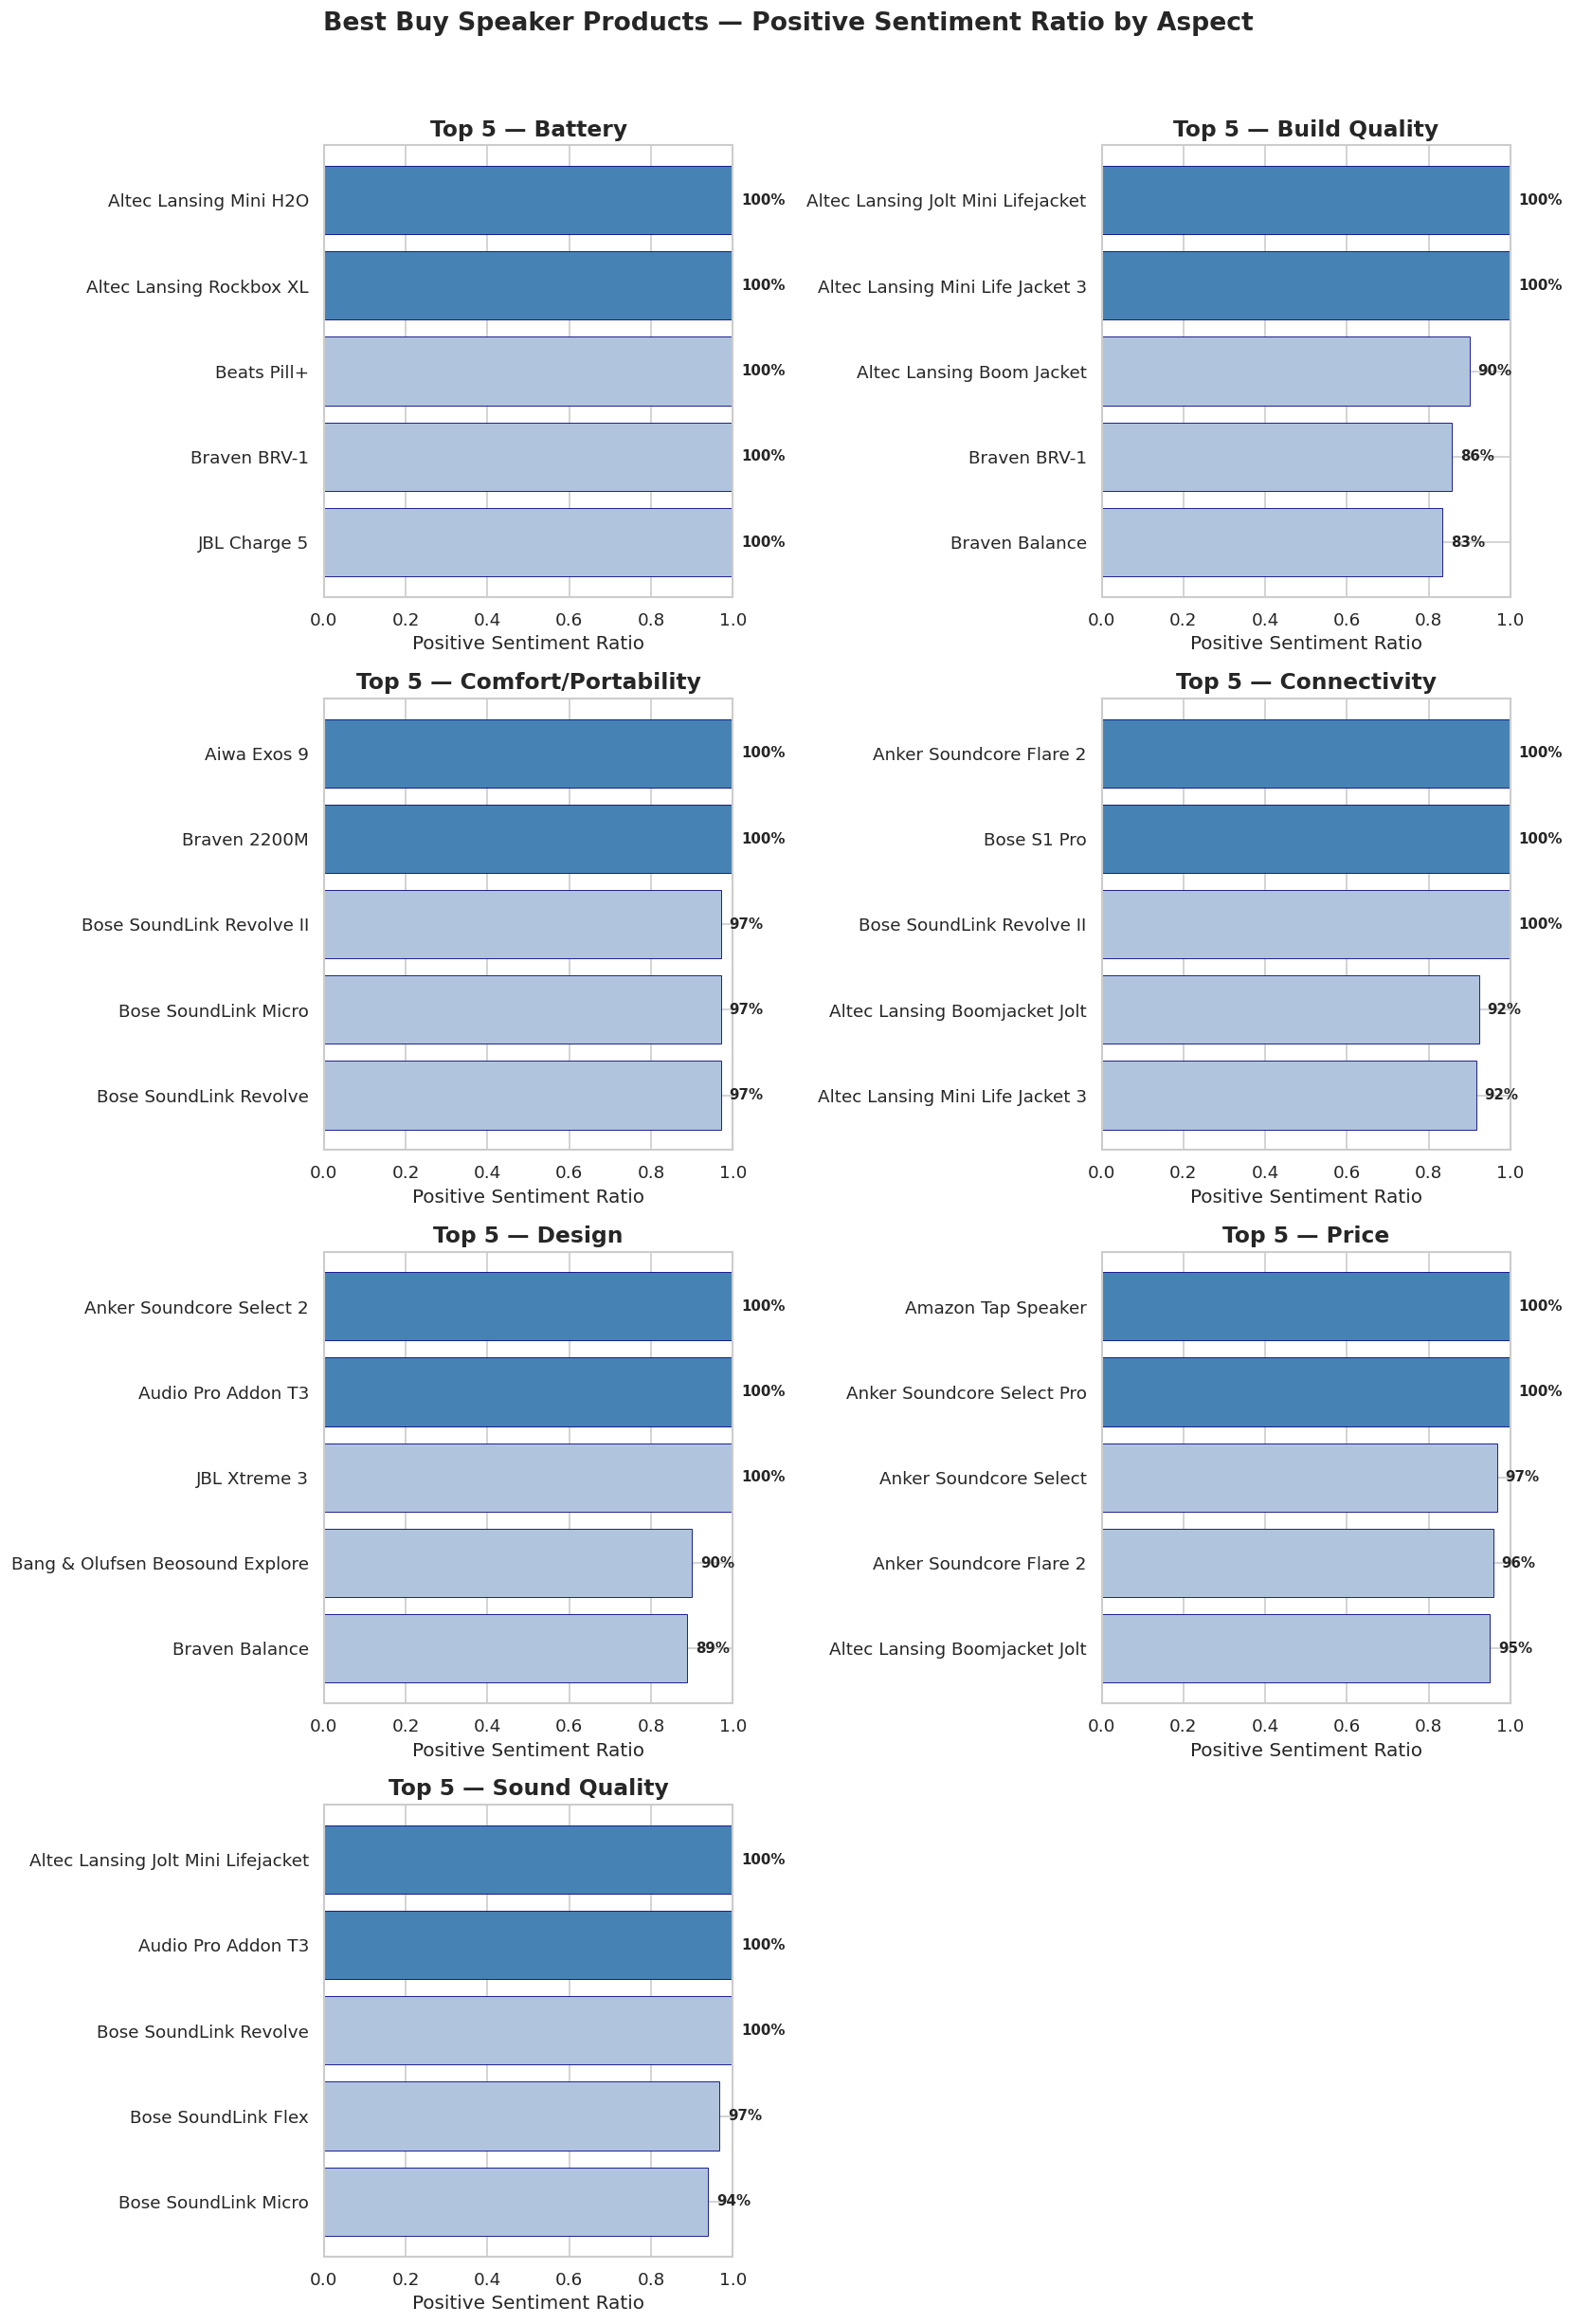


Chart saved to: /content/drive/MyDrive/data_asg/bestbuy/product_rankings_chart.png


In [17]:
# ============================================
# Facet Grid: Top 5 Products per Aspect
# ============================================
aspects_sorted = sorted(aspect_scores['aspect_label'].unique())
n_aspects = len(aspects_sorted)
n_cols = 2
n_rows = (n_aspects + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

colors = sns.color_palette("Blues_r", 5)

for idx, aspect in enumerate(aspects_sorted):
    top5 = aspect_scores[aspect_scores['aspect_label'] == aspect].nlargest(5, 'positive_ratio')
    ax = axes[idx]
    
    if len(top5) > 0:
        bars = ax.barh(range(len(top5)), top5['positive_ratio'].values, 
                      color=['steelblue', 'steelblue', 'lightsteelblue', 'lightsteelblue', 'lightsteelblue'],
                      edgecolor='navy', linewidth=0.5)
        ax.set_yticks(range(len(top5)))
        ax.set_yticklabels([p[:35] for p in top5['product_name'].values])
        ax.set_xlim(0, 1.0)
        ax.set_xlabel('Positive Sentiment Ratio')
        ax.set_title(f'Top 5 — {aspect}', fontweight='bold')
        ax.invert_yaxis()
        
        # Value labels
        for bar, ratio in zip(bars, top5['positive_ratio'].values):
            ax.text(ratio + 0.02, bar.get_y() + bar.get_height()/2,
                   f'{ratio:.0%}', va='center', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
               transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(f'Top 5 — {aspect}', fontweight='bold')

# Hide unused subplots
for idx in range(n_aspects, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Best Buy Speaker Products — Positive Sentiment Ratio by Aspect',
             fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
chart_path = f'{BESTBUY_DIR}/product_rankings_chart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved to: {chart_path}")


### 6.1 Overall Sentiment Distribution

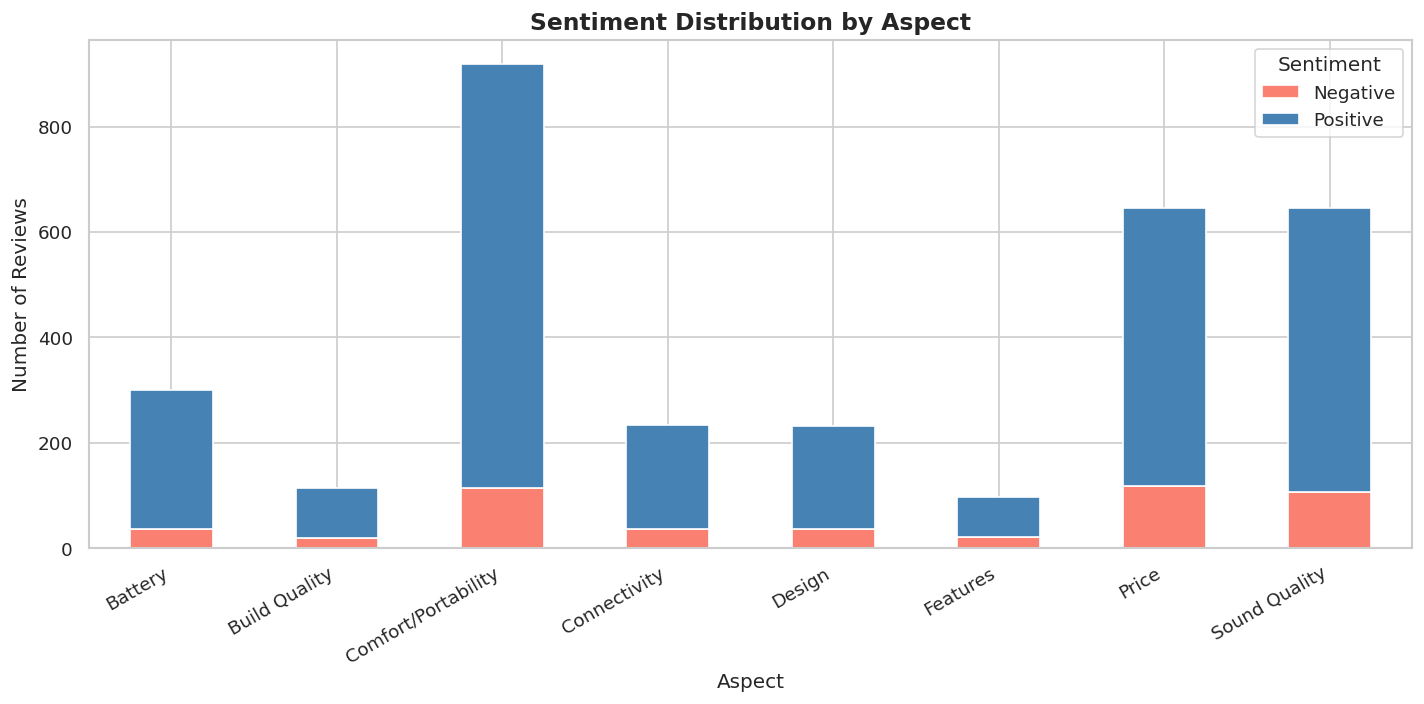

Sentiment distribution chart saved.


In [18]:
# ============================================
# Overall Sentiment Distribution by Aspect
# ============================================
plt.figure(figsize=(12, 6))
ct_plot = pd.crosstab(df['aspect_label'], df['sentiment_label'])
ct_plot.plot(kind='bar', stacked=True, ax=plt.gca(), color=['salmon', 'steelblue'], edgecolor='white')
plt.title('Sentiment Distribution by Aspect', fontweight='bold', fontsize=14)
plt.xlabel('Aspect')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig(f'{BESTBUY_DIR}/sentiment_by_aspect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sentiment distribution chart saved.")


## 7. Best Overall Product Selection

We compute a composite score for each product by:
- **Positive ratio (60%):** Average positive sentiment across all aspects
- **Aspect coverage (20%):** How many of the 7 aspects the product covers
- **Average rating (20%):** Star rating from Best Buy (normalized to 0-1)

Products must cover at least 4 aspects to be eligible.

In [19]:
# ============================================
# Composite Scoring
# ============================================
composite = aspect_scores.groupby('product_name').agg(
    avg_positive_ratio=('positive_ratio', 'mean'),
    aspects_covered=('aspect_label', 'count'),
    total_reviews=('total_reviews', 'sum'),
    avg_rating=('avg_rating', 'mean')
).reset_index()

# Require minimum aspect coverage
min_aspects = 4
composite = composite[composite['aspects_covered'] >= min_aspects]
print(f"Products covering at least {min_aspects} aspects: {len(composite)}")

# Composite score (weighted)
composite['composite_score'] = (
    0.6 * composite['avg_positive_ratio'] + 
    0.2 * (composite['aspects_covered'] / composite['aspects_covered'].max()) +
    0.2 * (composite['avg_rating'] / 5.0)
)

top_products = composite.nlargest(5, 'composite_score')

print(f"\n{'='*70}")
print(f"  TOP 5 PRODUCTS (COMPOSITE SCORE)")
print(f"{'='*70}")
for i, (_, row) in enumerate(top_products.iterrows(), 1):
    print(f"\n{i}. {row['product_name'][:55]}")
    print(f"   Composite Score:   {row['composite_score']:.3f}")
    print(f"   Avg Pos Ratio:     {row['avg_positive_ratio']:.1%}")
    print(f"   Aspects Covered:   {row['aspects_covered']:.0f}/7")
    print(f"   Avg Rating:        {row['avg_rating']:.2f} ★")
    print(f"   Total Reviews:     {row['total_reviews']:.0f}")


Products covering at least 4 aspects: 30

  TOP 5 PRODUCTS (COMPOSITE SCORE)

1. Altec Lansing Jolt Mini Lifejacket
   Composite Score:   0.900
   Avg Pos Ratio:     91.1%
   Aspects Covered:   6/7
   Avg Rating:        4.56 ★
   Total Reviews:     96

2. Braven Balance
   Composite Score:   0.894
   Avg Pos Ratio:     84.6%
   Aspects Covered:   7/7
   Avg Rating:        4.66 ★
   Total Reviews:     95

3. Bose S1 Pro
   Composite Score:   0.881
   Avg Pos Ratio:     90.5%
   Aspects Covered:   5/7
   Avg Rating:        4.88 ★
   Total Reviews:     96

4. Aiwa Exos 9
   Composite Score:   0.877
   Avg Pos Ratio:     87.2%
   Aspects Covered:   6/7
   Avg Rating:        4.54 ★
   Total Reviews:     93

5. Anker Soundcore Flare 2
   Composite Score:   0.873
   Avg Pos Ratio:     89.7%
   Aspects Covered:   5/7
   Avg Rating:        4.80 ★
   Total Reviews:     87


In [20]:
# ============================================
# Best Product: Detailed Aspect Profile
# ============================================
best_product = top_products.iloc[0]['product_name']

print(f"\n{'='*70}")
print(f"  BEST PRODUCT PROFILE")
print(f"  {best_product}")
print(f"{'='*70}")

profile = aspect_scores[aspect_scores['product_name'] == best_product].sort_values(
    'positive_ratio', ascending=False
)

print(f"\n  Aspect Performance:")
print(f"  {'Aspect':<25s} {'Positive Ratio':<18s} {'Reviews':<15s} {'Rating':<8s}")
print(f"  {'-'*25} {'-'*18} {'-'*15} {'-'*8}")
for _, row in profile.iterrows():
    print(f"  {row['aspect_label']:<25s} {row['positive_ratio']:.1%}           "
          f"{row['positive_reviews']:.0f}/{row['total_reviews']:.0f}        "
          f"{row['avg_rating']:.2f}")



  BEST PRODUCT PROFILE
  Altec Lansing Jolt Mini Lifejacket

  Aspect Performance:
  Aspect                    Positive Ratio     Reviews         Rating  
  ------------------------- ------------------ --------------- --------
  Build Quality             100.0%           6/6        4.67
  Sound Quality             100.0%           17/17        4.76
  Comfort/Portability       90.6%           29/32        4.75
  Battery                   90.0%           9/10        4.60
  Connectivity              88.9%           8/9        4.33
  Price                     77.3%           17/22        4.23


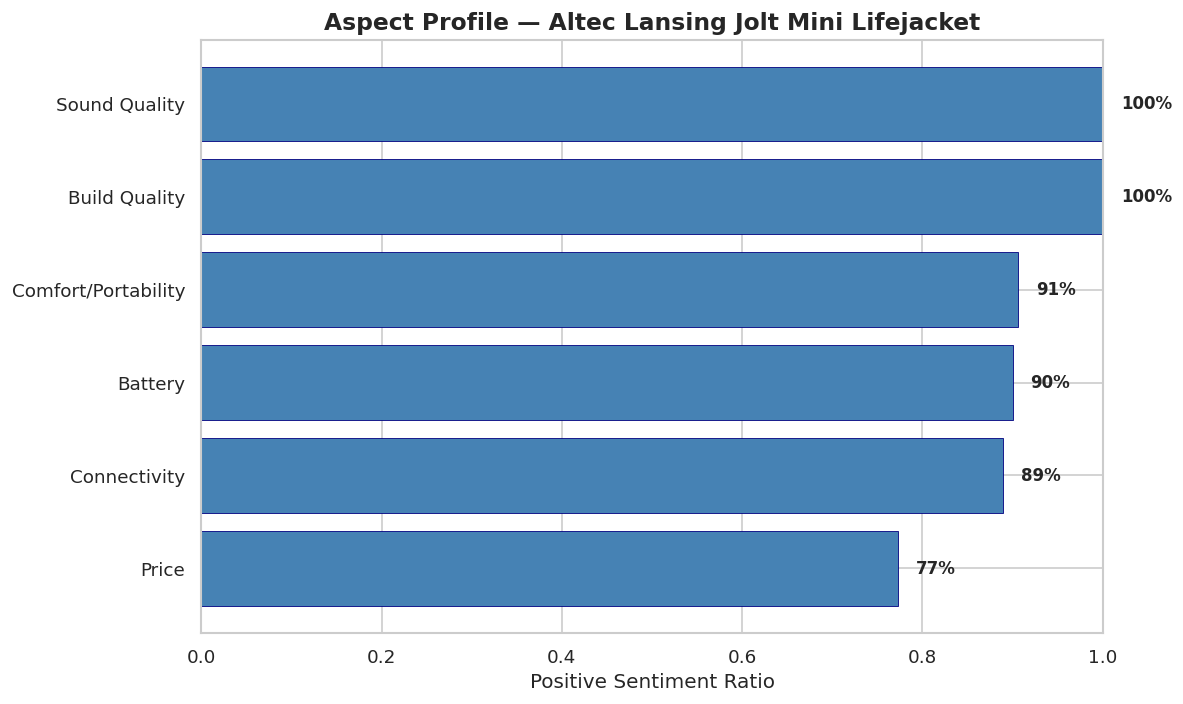

Best product profile chart saved to: /content/drive/MyDrive/data_asg/bestbuy/best_product_profile.png


In [21]:
# ============================================
# Best Product: Aspect Profile Chart
# ============================================
plt.figure(figsize=(10, 6))
profile_sorted = profile.sort_values('positive_ratio')

bars = plt.barh(range(len(profile_sorted)), profile_sorted['positive_ratio'].values,
               color='steelblue', edgecolor='navy', linewidth=0.5)
plt.yticks(range(len(profile_sorted)), profile_sorted['aspect_label'].values)
plt.xlabel('Positive Sentiment Ratio')
plt.title(f'Aspect Profile — {best_product[:50]}', fontweight='bold', fontsize=14)
plt.xlim(0, 1.0)

# Value labels
for bar, ratio in zip(bars, profile_sorted['positive_ratio'].values):
    plt.text(ratio + 0.02, bar.get_y() + bar.get_height()/2,
            f'{ratio:.0%}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
profile_chart_path = f'{BESTBUY_DIR}/best_product_profile.png'
plt.savefig(profile_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Best product profile chart saved to: {profile_chart_path}")


### 7.1 Best Product Justification

The best overall product is selected based on:

1. **Highest composite score** — weighted combination of positive sentiment ratio, aspect coverage, and star rating
2. **Broad aspect coverage** — must score well across at least 4 of 8 aspects (sound quality, design, battery, price, etc.)
3. **Consistent positive sentiment** — high positive ratio across multiple aspects indicates reliable quality
4. **Customer rating validation** — Best Buy star ratings support the sentiment analysis findings

This approach ensures the recommended product excels across the dimensions that matter most to speaker buyers, rather than being a one-trick pony that only excels in a single aspect.



## 8. Export & Summary

Saving all output DataFrames as CSV files for the report and downstream use.

In [22]:
# ============================================
# Export All Outputs
# ============================================
# 1. Labeled reviews with aspect + sentiment
df.to_csv(f'{BESTBUY_DIR}/labeled_reviews.csv', index=False)

# 2. Per-product per-aspect scores
aspect_scores.to_csv(f'{BESTBUY_DIR}/aspect_scores.csv', index=False)

# 3. Product rankings (top 5 per aspect)
rankings_df.to_csv(f'{BESTBUY_DIR}/product_rankings.csv', index=False)

# 4. Best products (top 5 composite)
top_products.to_csv(f'{BESTBUY_DIR}/best_products.csv', index=False)

print("=" * 60)
print("  PHASE 5: ALL OUTPUTS EXPORTED")
print("=" * 60)
print(f"\n  1. labeled_reviews.csv       : {len(df)} reviews with aspect + sentiment labels")
print(f"  2. aspect_scores.csv        : {len(aspect_scores)} product-aspect pairs")
print(f"  3. product_rankings.csv     : {len(rankings_df)} ranked entries (top 5 per aspect)")
print(f"  4. best_products.csv        : {len(top_products)} top composite-scored products")
print(f"\n  Charts:")
print(f"  5. product_rankings_chart.png — 7-aspect facet grid")
print(f"  6. sentiment_by_aspect.png     — stacked sentiment distribution")
print(f"  7. best_product_profile.png    — best product aspect profile")
print(f"\n  All files in: {BESTBUY_DIR}/")


  PHASE 5: ALL OUTPUTS EXPORTED

  1. labeled_reviews.csv       : 3185 reviews with aspect + sentiment labels
  2. aspect_scores.csv        : 179 product-aspect pairs
  3. product_rankings.csv     : 35 ranked entries (top 5 per aspect)
  4. best_products.csv        : 5 top composite-scored products

  Charts:
  5. product_rankings_chart.png — 7-aspect facet grid
  6. sentiment_by_aspect.png     — stacked sentiment distribution
  7. best_product_profile.png    — best product aspect profile

  All files in: /content/drive/MyDrive/data_asg/bestbuy/


---

**Phase 5 Complete.** The output CSVs and charts can now be used in the Phase 6 Report.

### Output Summary

| Artifact | Description |
|----------|-------------|
| `labeled_reviews.csv` | All reviews with CorEx aspect + SVM sentiment labels |
| `aspect_scores.csv` | Per-product per-aspect metrics (positive ratio, counts, avg rating) |
| `product_rankings.csv` | Top 5 products per aspect ranked by positive ratio |
| `best_products.csv` | Top 5 composite-scored products |
| `product_rankings_chart.png` | Facet grid bar charts (8 aspects × 5 products) |
| `sentiment_by_aspect.png` | Stacked sentiment distribution per aspect |
| `best_product_profile.png` | Best product's aspect-level performance 